In [21]:
!pip install --force-reinstall --no-deps numpy==1.26.4
!pip install gymnasium[atari] stable-baselines3 ale-py
!pip install opencv-python!

  Using cached numpy-1.26.4-cp310-cp310-win_amd64.whl.metadata (61 kB)
Using cached numpy-1.26.4-cp310-cp310-win_amd64.whl (15.8 MB)
  Attempting uninstall: numpy
    Found existing installation: numpy 1.26.4
    Uninstalling numpy-1.26.4:
      Successfully uninstalled numpy-1.26.4


  You can safely remove it manually.
  You can safely remove it manually.


ERROR: Invalid requirement: 'opencv-python!': Expected end or semicolon (after name and no valid version specifier)
    opencv-python!
                 ^


In [22]:
!pip install seaborn
import time
import wrapt
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import gymnasium as gym
from gymnasium import spaces
from IPython.display import clear_output
!pip install torch torchvision torchaudio
import torch
import torch.nn as nn
import torch.optim as optim
import random
import torch.nn.functional as F
from collections import deque
# Supress numpy scientific notation
np.set_printoptions(suppress=True)

In [3]:
import cv2  # OpenCV for image preprocessing
from collections import deque
import ale_py
print(ale_py.__version__)

0.10.2


In [4]:
import os
print(os.listdir())  # Lists all files in your working directory

['02b-RL-Review-TD.pdf', '03-Function Approximation.pdf', '04-Policy Gradient.pdf', '0802_I-O_Benchmark.xls', '2020098501HonorCourtRationaleLtr (1).pdf', '27707735.htm', '287-2875496_¡ándale-¡ándale-¡arriba-¡arriba-¡epa-¡epa-¡epa-yeehaw-speedy-gonzales.png', '5F161400', '6050-2_19-Presentation.pptx', '6160 Exam Review Guide.docx', '6160_Complete_Exam_Review_Guide.docx', '6160_Exam_Review_Guide_with_Examples (1).docx', '6160_Exam_Review_Guide_with_Examples.docx', '6160_Exam_Review_Guide_with_Teaching_Points.docx', '6211-Midterm-StudyGuide.pdf', '6D3CB04F-A778-4797-969D-0C18F89CD735.jpg', '942877-Sekiro-Shadows-Die-Twice-sekiro-video-games-video-game-art.jpg', '94fd4520d5a6801cc13dd9101a9502d9.jpg', 'ACER (1).pdf', 'ACER.pdf', 'Acrobat_Set-Up.exe', 'ACSDP5Y2023.DP05-2025-01-21T170945.csv', 'Active Assailant Video 1 Transcript.pdf', 'Advertising.csv', 'All Non-Profits in NC.csv', 'Anaconda3-2024.10-1-Windows-x86_64.exe', 'Analytics Overview (1).pptx', 'Analytics Overview.pptx', 'Applicati

In [5]:
print(os.getcwd())  # Check the current working directory

c:\Users\David\Downloads


In [6]:
pip list | findstr numpy

numpy                           1.26.4
Note: you may need to restart the kernel to use updated packages.


In [ ]:
"""Components of Dueling DQN
1. Neural Network Architecture:
   - Convolutional layers for processing game frames
   - Fully connected layers for action selection

2. Experience Replay Buffer:
   - Stores (state, action, reward, next_state, done) tuples
   - Enables random sampling for training
   - Helps break correlation between consecutive samples

3. Target Network + Policy Network
   - A copy of the main network
   - Updated periodically (every N steps)
   - Stabilizes training by reducing moving target problem

4. Core DQN Components:
   - Epsilon-greedy exploration strategy
   - Loss function (typically MSE)
   - Optimizer (typically Adam)
   - Discount factor (gamma) for future rewards

5. Training Loop:
   - Frame preprocessing (resize, grayscale, stack frames)
   - Action selection
   - Environment interaction
   - Memory storage
   - Network updates
   - Target network updates"""

'Components of DQN\n1. Neural Network Architecture:\n   - Convolutional layers for processing game frames\n   - Fully connected layers for action selection\n\n2. Experience Replay Buffer:\n   - Stores (state, action, reward, next_state, done) tuples\n   - Enables random sampling for training\n   - Helps break correlation between consecutive samples\n\n3. Target Network:\n   - A copy of the main network\n   - Updated periodically (every N steps)\n   - Stabilizes training by reducing moving target problem\n\n4. Core DQN Components:\n   - Epsilon-greedy exploration strategy\n   - Loss function (typically MSE)\n   - Optimizer (typically Adam)\n   - Discount factor (gamma) for future rewards\n\n5. Training Loop:\n   - Frame preprocessing (resize, grayscale, stack frames)\n   - Action selection\n   - Environment interaction\n   - Memory storage\n   - Network updates\n   - Target network updates'

In [ ]:
#Register the Atari Learning Environment with OpenAI Gym
gym.register_envs(ale_py)
# Creates an instance of the Pong environment
env = gym.make("ALE/Pong-v5", render_mode='rgb_array')
print("Environment loaded successfully!")

Environment loaded successfully!


In [9]:
#Don't define n_states because the observation space is continuous and not discrete
n_actions = env.action_space.n
print("Observation space:", env.observation_space)
print("Action space:", env.action_space)

Observation space: Box(0, 255, (210, 160, 3), uint8)
Action space: Discrete(6)


In [10]:
# Reset environment to start fresh
obs, info = env.reset()
# Sample a random action
random_action = env.action_space.sample()
# Step the environment using the random action
next_obs, reward, terminated, truncated, info = env.step(random_action)

In [11]:
print(f"Observation/state: {obs}")
print(f"Next observation/state: {next_obs}")
print(f"Reward: {reward}")
print(f"Terminated: {terminated}")
print(f"Truncated: {truncated}")
print(f"Info: {info}")

Observation/state: [[[  0   0   0]
  [  0   0   0]
  [  0   0   0]
  ...
  [109 118  43]
  [109 118  43]
  [109 118  43]]

 [[109 118  43]
  [109 118  43]
  [109 118  43]
  ...
  [109 118  43]
  [109 118  43]
  [109 118  43]]

 [[109 118  43]
  [109 118  43]
  [109 118  43]
  ...
  [109 118  43]
  [109 118  43]
  [109 118  43]]

 ...

 [[ 53  95  24]
  [ 53  95  24]
  [ 53  95  24]
  ...
  [ 53  95  24]
  [ 53  95  24]
  [ 53  95  24]]

 [[ 53  95  24]
  [ 53  95  24]
  [ 53  95  24]
  ...
  [ 53  95  24]
  [ 53  95  24]
  [ 53  95  24]]

 [[ 53  95  24]
  [ 53  95  24]
  [ 53  95  24]
  ...
  [ 53  95  24]
  [ 53  95  24]
  [ 53  95  24]]]
Next observation/state: [[[  0   0   0]
  [  0   0   0]
  [  0   0   0]
  ...
  [144  72  17]
  [144  72  17]
  [144  72  17]]

 [[144  72  17]
  [144  72  17]
  [144  72  17]
  ...
  [144  72  17]
  [144  72  17]
  [144  72  17]]

 [[144  72  17]
  [144  72  17]
  [144  72  17]
  ...
  [144  72  17]
  [144  72  17]
  [144  72  17]]

 ...

 [[236 23

In [12]:
done = truncated or terminated
print(f"Done: {truncated}")

Done: False


In [ ]:
def epsilon_greedy(epsilon, state, n_actions, policy_net, device):
    """Selects an action using epsilon-greedy policy for DQN"""
    #Epsilon controls the probabiliyu of exploration
    if np.random.uniform() < epsilon:  
        # Exploration: Choose random action
        action = np.random.randint(n_actions)
    else:
        device = next(policy_net.parameters()).device
        # Exploitation: Choose action with highest Q-value
        state_tensor = torch.tensor(np.expand_dims(state, 0), dtype=torch.float32).to(device)
        with torch.no_grad():
            q_values = policy_net(state_tensor)  # Get Q-values from the policy network
        action = q_values.argmax().item()  # Select action with the highest Q-value
    
    return action  # Return the selected action

#Create and define the Preprocessing Function
class PreprocessEnv(gym.Wrapper):
    def __init__(self, env, skip=4):
        super(PreprocessEnv, self).__init__(env)
        self._skip = skip
    """ The step method executes the given action for skip frames and accumulates rewards. We
    do this so that the number of frames the agent tneeds to process is reduced and the agent can
    learn faster."""
    def step(self, action):
        total_reward = 0.0
        done = False
        truncated = False
        for i in range(self._skip):
            obs, reward, done, truncated, info = self.env.step(action)
            total_reward += reward
            if done:
                break
        
        # Process observation
        obs = self._preprocess_observation(obs)
        return obs, total_reward, done, truncated, info

    def reset(self):
        obs, info = self.env.reset()
        obs = self._preprocess_observation(obs)  
        return obs, info
    """ We are defining the function that converts the color image observation to grayscale 
    by using cv2.cvtColor. This is done to reduce the complexity of the input data."""
    def _preprocess_observation(self, obs):
        # Convert to grayscale
        obs = cv2.cvtColor(obs, cv2.COLOR_RGB2GRAY)
        # Resize the image to 84x84 pixels to reduce input size
        obs = cv2.resize(obs, (84, 84), interpolation=cv2.INTER_AREA)
        # Normalize pixel values by dividing by 255 to fit in the range [0, 1] for CNN 
        obs = obs / 255.0
        return obs


In [ ]:
"""The FrameStack class enhances the agent's comprehension of the game ennviornnment by stacking
consecutive frames together.  This is essential to do becuase the speed and direction of the ball
can't be determined from a single frame. This allows the agent to correctly perceive motion and
changes over time."""

In [23]:

class FrameStack(gym.Wrapper):
    def __init__(self, env, k):
        super(FrameStack, self).__init__(env)
        self.k = k #The number of frames to stack
        self.frames = deque([], maxlen=k) #Double-ended queue with max length of k
        shp = env.observation_space.shape
        #Now we adjust the format of the observations that the agent will receive to account for the stacked frames
        self.observation_space = gym.spaces.Box(
            low=0,
            high=1,
            shape=(k, shp[0], shp[1]),
            dtype=np.float32
        )
    """Define reset function to initialize the stack with the starting state. Once reset the environment
    receives the initial observastion ands appends it to the self.frames deque k times."""
    def reset(self):
        obs, info = self.env.reset()
        for _ in range(self.k):
            self.frames.append(obs)
        return self._get_obs(), info
    # Steps the environment and the new observation is added to self.frames
    def step(self, action):
        obs, reward, done, truncated, info = self.env.step(action)
        self.frames.append(obs)
        return self._get_obs(), reward, done, truncated, info
    # This is a helper function that converts the deque of frames into a NumPy array
    def _get_obs(self):
        return np.array(self.frames)

In [ ]:
"""These are the convolutional layers of our CNN. They are responsible for processing 
        the visual informationm from the game. """
"""nn.Conv2D are convolutional layers that extract features from the input images.
            nn.ReLU are activation functions that introduce non-lineraity into the network,
            which gives the agennt the capability of learning complex environments."""

In [24]:
#Creating DQN Agent
class DQN(nn.Module):
    """This is the constructor of the class that takes the dimensions of the game and
    the number of possible actions the agent can take as input."""
    def __init__(self, input_shape, n_actions = 6):
        super(DQN, self).__init__()
        self.conv = nn.Sequential(
            nn.Conv2d(input_shape[0], 32, kernel_size=8, stride=4),
            nn.ReLU(),
            nn.Conv2d(32, 64, kernel_size=4, stride=2),
            nn.ReLU(),
            nn.Conv2d(64, 64, kernel_size=3, stride=1),
            nn.ReLU()
        )
        conv_out_size = self._get_conv_out(input_shape)
        #Here we define the fully connected layers, which are known as dense layers.
        self.fc = nn.Sequential(
            nn.Linear(conv_out_size, 512),
            nn.ReLU(),
            nn.Linear(512, n_actions)
        )
    """Here we define a helper function that calculates the output size of the 
    convolutional layers. The size is needed to correctly define the input size of the first 
    fully connected layer."""
    def _get_conv_out(self, shape):
        dummy_input = torch.zeros(1, *shape).to(next(self.parameters()).device)
        o = self.conv(torch.zeros(1, *shape))
        return int(np.prod(o.size()))
    """This is the most important function for our network because it defines how the input
    data goes through the network. By taking the game screen as input it returns Q-values for 
    each possible action."""
    def forward(self, x):
        x = x.float()
        conv_out = self.conv(x)
        conv_out = conv_out.view(conv_out.size(0), -1)
        return self.fc(conv_out)


In [ ]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# Initialize model
model = DQN(input_shape=(4, 84, 84), n_actions=6).to(device)

# Test input with fake input (batch_size=1, 4 frames, 84x84)
test_input = torch.zeros((1, 4, 84, 84)).to(device)  
output = model(test_input)

# Expected: torch.Size([1, 6])
print("DQN Output Shape:", output.shape)  

DQN Output Shape: torch.Size([1, 6])


In [ ]:
# Create Replay Buffer
class ReplayBuffer:
    #Constructor of the class. It initializes an empty double-ended queue that stores past experiences
    def __init__(self, capacity):
        self.buffer = deque(maxlen=capacity)  # Store at most `capacity` transitions
    # Define function to append new experiences to the buffer in form of five element tuple
    def add(self, state, action, reward, next_state, done):
        """Store experience tuple"""
        self.buffer.append((state, action, reward, next_state, done))
    #This function creates our mini-batch that samples a batch of experiences from the buffer
    def sample(self, batch_size):
        """After creation the batches are unzipped to separate each element into a separate list"""
        batch = random.sample(self.buffer, batch_size)  # Randomly sample experiences
        states, actions, rewards, next_states, dones = zip(*batch)
        
        """Then we convert each element to PyTorch tensors. Use Float Tensor for states, rewards, 
        next_states, and dones. Long Tensor for actions since they're discrete"""
        states = torch.FloatTensor(np.array(states))
        actions = torch.LongTensor(np.array(actions))
        rewards = torch.FloatTensor(np.array(rewards))
        next_states = torch.FloatTensor(np.array(next_states))
        dones = torch.FloatTensor(np.array(dones))
        
        return states, actions, rewards, next_states, dones
    #This function returns the current number of experiences stored in the buffer
    def size(self):
        return len(self.buffer)

In [ ]:
# Hyperparameters
gamma = 0.99  # Discount factor - determines how much future rewards are valued over immediate rewards
batch_size = 64 # Number of past experiences randomly sampled from replay buffer per learning step
LR = 2.5e-4  # Learning rate
replay_size = 150000  # Max memory for replay buffer, agent doesn't start learning till RB is full
epsilon_max = 1.0 # Initial exploration rate; set it high initially to encourage agent's exploration of different actions
epsilon_min = 0.01 # Minimum exploration rate, which is set to ensure the agent continues some level of exploration even late in training, but primarily takes best action (Exploits)
epsilon_decay = 250000 # Sets the initial epsilon decay which impacts agent's learning speed over the course of training
target_update = 1000  # Update target network every 1000 steps

In [ ]:
""" Initialize Components"""
# Environment created. We use RGB to specify to the env to output frames as RGB arrays for processing
env = gym.make("ALE/Pong-v5", render_mode="rgb_array")
# Apply preprocessing
env = PreprocessEnv(env)
#Apply frame stacking
env = FrameStack(env, 4)
# Retrieve shape of obs space after preprocessing and frame stack
input_shape = env.observation_space.shape[0]

""" Here there is 2 DQN models. We have a Dueling DQN that has both a policy network and 
target network, which is a copy of the main network that is updated periodically. This 
helps stabilize training by preventing rapid shifts in Q-values."""
policy_net = DQN(input_shape=(4, 84, 84), n_actions=6).to(device)
target_net = DQN(input_shape=(4, 84, 84), n_actions=6).to(device)
#Copy weights of policy_net to target_net which ensures the start with same initial values
target_net.load_state_dict(policy_net.state_dict())

"""Here we create an Adam optimizer that updates the weights of the policy_net during training.
It takes the policy_net's parameters and a learning rate for input"""
# Optimizer & Replay Buffer
optimizer = optim.Adam(policy_net.parameters(), lr=LR)
# Replay Buffer helps to break correlations between conseqcutive samples and improves stability
replay_buffer = ReplayBuffer(replay_size)

""" Set initial epsilon to max value (epsilon = 1).  A high epsilon value encourages exploration 
and as it decreases the agent begins the take the best actions more often (exploitation)"""
epsilon = epsilon_max


In [ ]:
"""This is an evaluation function that will play the game for a certain number of episodes
and will return the average reward obtained from those games. This is purely to allow us to see 
how well the agent has learned the game and is not our official testing."""
def evaluate(env, policy_net, device, n_episodes=75):
    eval_rewards = []
    for _ in range(n_episodes):
        state, _ = env.reset()
        done = False
        total_reward = 0
        while not done:
            with torch.no_grad():
                state_tensor = torch.FloatTensor(state).unsqueeze(0).to(device)
                action = policy_net(state_tensor).max(1)[1].item()
            state, reward, done, truncated, _ = env.step(action)
            total_reward += reward
        eval_rewards.append(total_reward)
    return np.mean(eval_rewards)

In [22]:
# Initialize variables before the loop
n_frames = 1500000
# Variable created and initialized to negative infinity that updates best reward during evaluation
best_reward = float('-inf')
#Empty list to store total reward obtained in each episode
episode_rewards = []
# Variable created to keep track of CURRENT episode's rewards. Resets to 0 for each new episode
episode_reward = 0
# Restt game env to starting state
state, _ = env.reset()

"""This is our main training loop which unlike our test loop includes the agent's 
epsilon-greedy policy. It iterates n_frames times and frame_idx keeps track of the current
frame number."""
for frame_idx in range(1, n_frames + 1):
        
    # Select action using epsilon-greedy policy
    action = epsilon_greedy(epsilon, state, n_actions, policy_net, device)
    
    # Execute action
    next_state, reward, done, truncated, _ = env.step(action)
    
    # Print more detailed information
    if frame_idx % 10000 == 0:  # More frequent updates
        print(f"Q-values: {policy_net(torch.FloatTensor(state).unsqueeze(0).to(device)).detach().cpu().numpy()}")
    
    # Clip rewards (optional but recommended for Atari)
    reward = np.clip(reward, -1, 1)
    
    episode_reward += reward
    replay_buffer.add(state, action, reward, next_state, done)
    
    state = next_state
    
    """This is a crucial part to our training loop.  It samples past experiences from the
    replay buffer, then processes them into tensors before computing the Q-values for the
    current and next states. Finally it then constructs the target Q-values for training."""
    if replay_buffer.size() > batch_size:
        # Sample from replay buffer
        state_batch, action_batch, reward_batch, next_state_batch, done_batch = replay_buffer.sample(batch_size)
        
        # Convert to tensors
        state_batch = torch.FloatTensor(state_batch).to(device)
        action_batch = torch.LongTensor(action_batch).to(device)
        reward_batch = torch.FloatTensor(reward_batch).to(device)
        next_state_batch = torch.FloatTensor(next_state_batch).to(device)
        done_batch = torch.FloatTensor(done_batch).to(device)
        
        # Compute current Q values
        current_q_values = policy_net(state_batch).gather(1, action_batch.unsqueeze(1))
        
        # Compute next Q values
        with torch.no_grad():
            next_q_values = target_net(next_state_batch).max(1)[0]
            # Mask for non-terminal states
            next_q_values = next_q_values * (1 - done_batch)
            # Compute target Q values with our gamma hyper parameter
            target_q_values = reward_batch + (gamma * next_q_values)
            
        """ Compute loss using the Huber Loss function, which behaves like Mean Squared
        Error (MSE) loss for large errors but like Mean Absolute Error (MAE) for small errors.
        This mechanism makes it less sensitive to outliers. Once calculated the unsqueeze
        function reshapes it to maktch the expected shape."""
        loss = F.smooth_l1_loss(current_q_values, target_q_values.unsqueeze(1))
        
        """Now we clear previous gradients to prevent gradients from multiple steps would add up
         which would lead to incorrect updates)."""
        optimizer.zero_grad()
        # Compute gradients through backwards propagation
        loss.backward()
        
        # Add gradient clipping to prevent gradient updates from exploding in size with large updates
        torch.nn.utils.clip_grad_norm_(policy_net.parameters(), max_norm=10.0)
        # Then we update the weights of the policy network using the computed gradients.
        optimizer.step()
    
    # Update Target Network
    if frame_idx % target_update == 0:
        target_net.load_state_dict(policy_net.state_dict())
    
    # Decrease Epsilon
    epsilon = max(epsilon_min, epsilon_max - frame_idx / epsilon_decay)
    
    if done or truncated:
        episode_rewards.append(episode_reward)
        print(f"Episode {len(episode_rewards)} | Frame {frame_idx} | Reward {episode_reward:.2f} | Epsilon {epsilon:.4f}")
        state, _ = env.reset()
        episode_reward = 0
    
    # Evaluation and model saving
    if frame_idx % 100000 == 0:  # Every 100k frames
        eval_reward = evaluate(env, policy_net, device)
        print(f"Evaluation reward: {eval_reward}")
        
        if eval_reward > best_reward:
            best_reward = eval_reward
            torch.save(policy_net.state_dict(), 'best_model2.pth')
            print(f"New best model saved with reward: {best_reward}")
    
    # Progress tracking
    if frame_idx % 10000 == 0:
        print(f"Frame {frame_idx}: Epsilon = {epsilon:.4f}, Latest Reward = {reward}")


Episode 1 | Frame 206 | Reward -21.00 | Epsilon 0.9992
Episode 2 | Frame 397 | Reward -21.00 | Epsilon 0.9984
Episode 3 | Frame 611 | Reward -21.00 | Epsilon 0.9976
Episode 4 | Frame 818 | Reward -21.00 | Epsilon 0.9967
Episode 5 | Frame 1040 | Reward -20.00 | Epsilon 0.9958
Episode 6 | Frame 1251 | Reward -20.00 | Epsilon 0.9950
Episode 7 | Frame 1447 | Reward -21.00 | Epsilon 0.9942
Episode 8 | Frame 1654 | Reward -21.00 | Epsilon 0.9934
Episode 9 | Frame 1857 | Reward -21.00 | Epsilon 0.9926
Episode 10 | Frame 2064 | Reward -21.00 | Epsilon 0.9917
Episode 11 | Frame 2287 | Reward -21.00 | Epsilon 0.9909
Episode 12 | Frame 2520 | Reward -20.00 | Epsilon 0.9899
Episode 13 | Frame 2775 | Reward -20.00 | Epsilon 0.9889
Episode 14 | Frame 2974 | Reward -21.00 | Epsilon 0.9881
Episode 15 | Frame 3240 | Reward -19.00 | Epsilon 0.9870
Episode 16 | Frame 3443 | Reward -21.00 | Epsilon 0.9862
Episode 17 | Frame 3680 | Reward -21.00 | Epsilon 0.9853
Episode 18 | Frame 3900 | Reward -20.00 | Ep

KeyboardInterrupt: 

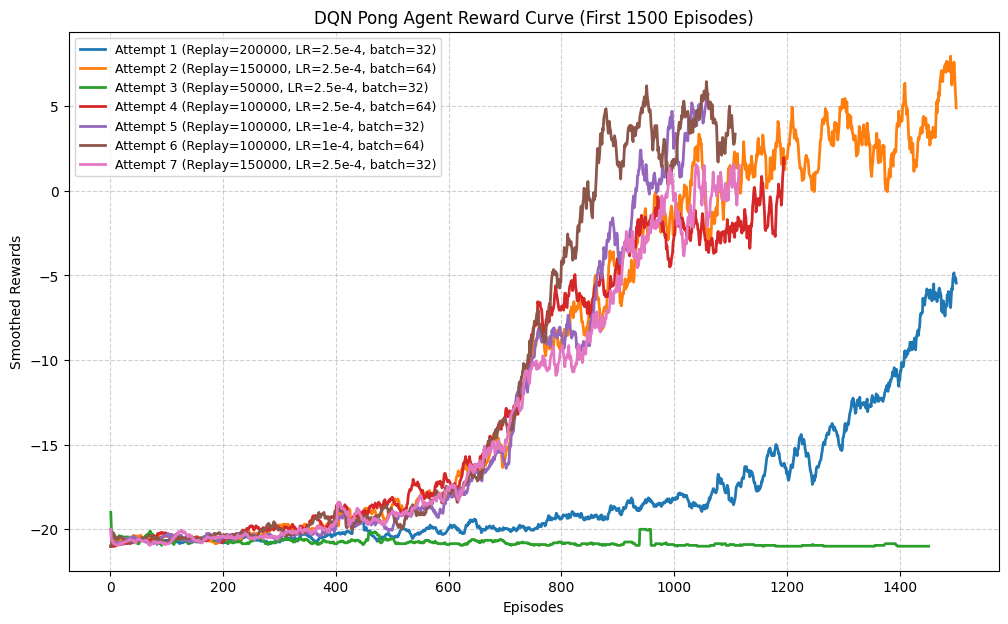

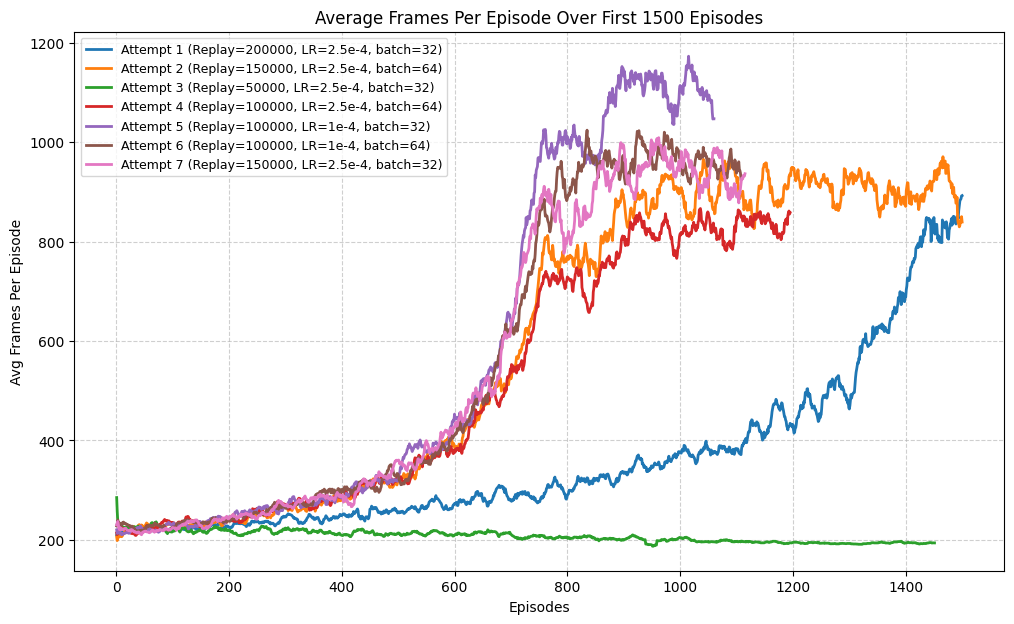

In [ ]:
# Install necessary libraries (uncomment if running for the first time)
# !pip install matplotlib pandas

# Import dependencies
import os
import re
import pandas as pd
import matplotlib.pyplot as plt

# Ensure inline plotting for Jupyter Notebooks
%matplotlib inline

# Set directory containing the txt files (Ensure your txt files are in this directory)
data_dir = r"C:\Users\David\OneDrive\Desktop\DSBA 6010 DRL"  

# Get all txt file paths
file_paths = {f.split(".")[0]: os.path.join(data_dir, f) for f in os.listdir(data_dir) if f.endswith(".txt")}

### --- Step 1: Parse Files --- ###

def parse_file(file_path):
    """Extracts episodes and rewards from a DQN Pong training log."""
    episodes, rewards = [], []
    with open(file_path, 'r') as file:
        for line in file:
            match = re.search(r"Episode (\d+) \| Frame \d+ \| Reward (-?\d+\.\d+|\-?\d+) \| Epsilon", line)
            if match:
                episodes.append(int(match.group(1)))
                rewards.append(float(match.group(2)))
    return episodes, rewards

def parse_frames(file_path):
    """Extracts episode numbers and frame counts from a DQN Pong training log."""
    episodes, frames = [], []
    with open(file_path, 'r') as file:
        for line in file:
            match = re.search(r"Episode (\d+) \| Frame (\d+) \| Reward", line)
            if match:
                episodes.append(int(match.group(1)))
                frames.append(int(match.group(2)))
    return episodes, frames

def extract_hyperparameters(file_path):
    """Extracts key hyperparameters from the DQN training log."""
    hyperparams = {}
    with open(file_path, 'r') as file:
        for line in file:
            match = re.match(r"(replay_size|batch_size|LR) = ([\d.e-]+)", line)
            if match:
                param, value = match.groups()
                hyperparams[param] = value
    return hyperparams

# Process all files
parsed_data = {name: parse_file(path) for name, path in file_paths.items()}
frame_data = {name: parse_frames(path) for name, path in file_paths.items()}
hyperparameter_info = {name: extract_hyperparameters(path) for name, path in file_paths.items()}

# Construct legend labels with hyperparameter info
legend_labels = {
    name: f"{name} (Replay={params.get('replay_size', '?')}, LR={params.get('LR', '?')}, batch={params.get('batch_size', '?')})"
    for name, params in hyperparameter_info.items()
}

### --- Step 2: Define Moving Average for Smoothing --- ###
def moving_average(data, window_size=20):
    """Computes a moving average for smoothing data."""
    return pd.Series(data).rolling(window=window_size, min_periods=1).mean()

### --- Step 3: Plot Smoothed Reward Curves (First 1500 Episodes) --- ###
plt.figure(figsize=(12, 7))
for name, (episodes, rewards) in parsed_data.items():
    filtered_episodes = [ep for ep in episodes if ep <= 1500]
    filtered_rewards = rewards[:len(filtered_episodes)]  # Match length
    smoothed_rewards = moving_average(filtered_rewards, window_size=20)
    plt.plot(filtered_episodes, smoothed_rewards, label=legend_labels[name], linewidth=2)

plt.xlabel("Episodes")
plt.ylabel("Smoothed Rewards")
plt.title("DQN Pong Agent Reward Curve (First 1500 Episodes)")
plt.legend(loc="best", fontsize=9)
plt.grid(True, linestyle="--", alpha=0.6)
plt.show()

### --- Step 4: Plot Average Frames Per Episode (First 1500 Episodes) --- ###
plt.figure(figsize=(12, 7))
for name, (episodes, frames) in frame_data.items():
    filtered_episodes = [ep for ep in episodes if ep <= 1500]
    filtered_frames = frames[:len(filtered_episodes)]  # Match length
    if filtered_episodes and filtered_frames:
        avg_frames_per_episode = [filtered_frames[i] - filtered_frames[i-1] if i > 0 else filtered_frames[i] for i in range(len(filtered_frames))]
        smoothed_avg_frames = moving_average(avg_frames_per_episode, window_size=20)
        plt.plot(filtered_episodes, smoothed_avg_frames, label=legend_labels[name], linewidth=2)

plt.xlabel("Episodes")
plt.ylabel("Avg Frames Per Episode")
plt.title("Average Frames Per Episode Over First 1500 Episodes")
plt.legend(loc="best", fontsize=9)
plt.grid(True, linestyle="--", alpha=0.6)
plt.show()

"""After running multiple variations of hyper parameters I observed the following:
1) The replay buffer size plays an important role in determining the agent's performance. Agents with replay buffer sizes 100k or larger showed to have more stable performance over time.
In contrast, a smaller replay buffer size of 50k experiences was unable to learn at all and stalled out over the course of 300k frames (Did not run full time of training
because it was performing so bad, I couldn't bear to watch it any longer). For Attempt 1, I used a replay buffer size of 200k and you can see how slowly the agent was learning, and it actually reached
the same level of perfomance as other models but I cut it off since I only trainned the other models for 600k frames instead of 1.4 million. You can still see it beginning to improve
fairly quickly in the average frames per episode plot, it just had to take longer to fill up its replay buffer before actually learning.
2) For the learning rate, I had success with both 2.5e-4 and 1e-4 rates in training.  Interestingly enough, I believed that 2.5e-4 was a better rate until I overlayed
all training attempts in the plots below.  You can see that both LRs were able to start improving around the same time, but the 1e-4 models (Attempts 5 and 6) experienced a 
larger/faster spike up in performance from 700 to 1000 epsiodes. Agents with a higher LR (2.5e-4) tend to adapt more quickly in the beginning, which you can see with little 
spikes upin Attempts 2, 4, and 7 but they also show higher variance in performance.In conclusion I see a lower LR (1e-4) as the more optimal rate becauseit makes the learning 
process more gradual, potentially leading to more consistent long-term improvements.
3) For the batch size I observed that larger batch sizes (64 instead of 32) appear to smooth out learning curves, suggesting that larger batches help stabilize updates. The smaller
batch sizes allowed the agent to learn from more recent experiences, potentially leading to faster adaptation early on but with more fluctuations.  The clearest comparison to look
at is with Attempts 5 and 6, which have the same hyper parameters up to the batch sizes.  Attempt 5 (purple) experiences a similar spike up at the same time that Attempt 6 (brown)
does, however with a larger batch size it seems that Attempt 6 was able to improve performance more efficiently.  This intuitive makes sense because a larger batch size means
the agent has more past experiences to randomly sample from and learns how to play the game better at a faster rate.
4) For the epsilon decay I kept all attempts at 250k to try to establish a comparable baseline for every agent training. Additionally, this means that differences between models
in frames per episode suggest that some hyper parameter configurations allow the agent to play longer episodes sooner (aka starts scoring points and putting up a fair fight
against the cpu) which indicates improvements in decision-making for the agents.
5) For gamma and target update I kept the same values across all models (g=0.99 and target_update=1000), which will be somethinng for future considerations to play around with and
analyze the differences in the agents' learning abilities.

Overall I think that a combination of a replay buffer 100k or larger, a lower LR (1e-4), and a larger batch size (64) are the optimal hyper paramerers for stable training.
Smaller replay buffers may initially speed up learning but could lead to instability later on. A balance between batch size and learning rate is crucial becuase
too high of a learning rate with not a large enough replay buffer and small batch sizes can make learning erratic. I learned a tremendous amount from this assignment and find it so
fascinating to observe truly how sensitive the model is to different hyper parameters. It can go from no improvement at all to winning consistently just from having a replay buffer
(aka size of its memory) that is 100k instead of 50k. For about 5 days I tried countless attempts to run models with a replay buffer that was 500k but as soon as the agent
filled it up and starting to draw batches from it, my computer was unable to handlee the amount of computational power required.  By lowering my replay buffer to 200k or smaller,
my computer (Dell Latitude 5540 with 64gb RAM) was able to complete training sessions.  The most I was able to do simultaneously was two agents training with 100k replay buffers;
I tried to run 3 but was using 100% of my cpu and got dangerously close to committing all possible RAM to it."""

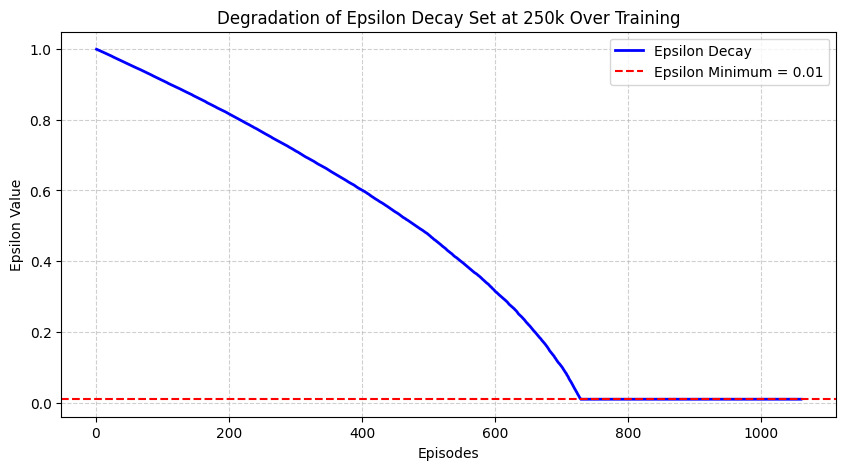

In [16]:
import os
import re
import matplotlib.pyplot as plt

# Set the directory containing the .txt files
data_dir = r"C:\Users\David\OneDrive\Desktop\DSBA 6010 DRL"  # Change this to your actual directory

# Select the file to analyze
file_name = "Attempt 5.txt"  # Change this to any file in your directory
file_path = os.path.join(data_dir, file_name)

# Function to extract epsilon values
def parse_epsilon_from_file(file_path):
    """Extracts episodes and epsilon values from a DQN Pong training log."""
    episodes = []
    epsilon_values = []
    with open(file_path, 'r') as file:
        for line in file:
            match = re.search(r"Episode (\d+) \| Frame \d+ \| Reward .* \| Epsilon ([\d.]+)", line)
            if match:
                episodes.append(int(match.group(1)))
                epsilon_values.append(float(match.group(2)))
    return episodes, epsilon_values

# Extract epsilon decay values from the selected file
episodes, epsilon_values = parse_epsilon_from_file(file_path)

# Plot the actual epsilon decay from the file
plt.figure(figsize=(10, 5))
plt.plot(episodes, epsilon_values, color='blue', linewidth=2, label=f"Epsilon Decay")

plt.axhline(y=0.01, color='red', linestyle="--", label="Epsilon Minimum = 0.01")
plt.xlabel("Episodes")
plt.ylabel("Epsilon Value")
plt.title(f"Degradation of Epsilon Decay Set at 250k Over Training")
plt.legend()
plt.grid(True, linestyle="--", alpha=0.6)
plt.show()
